In [585]:
import pandas as pd

In [586]:
import numpy as np

In [587]:
import seaborn as sns

In [588]:
import matplotlib.pyplot as plt

In [589]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold

In [590]:
from sklearn.preprocessing import LabelEncoder, RobustScaler, TargetEncoder

In [591]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [592]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [593]:
sns.set_theme(style='whitegrid')

In [594]:
df = pd.read_csv('../data/bank.csv')

In [595]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


C:\Users\medoc\AppData\Local\Temp\ipykernel_22488\2909791242.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='deposit', palette='viridis')


<Axes: xlabel='deposit', ylabel='count'>

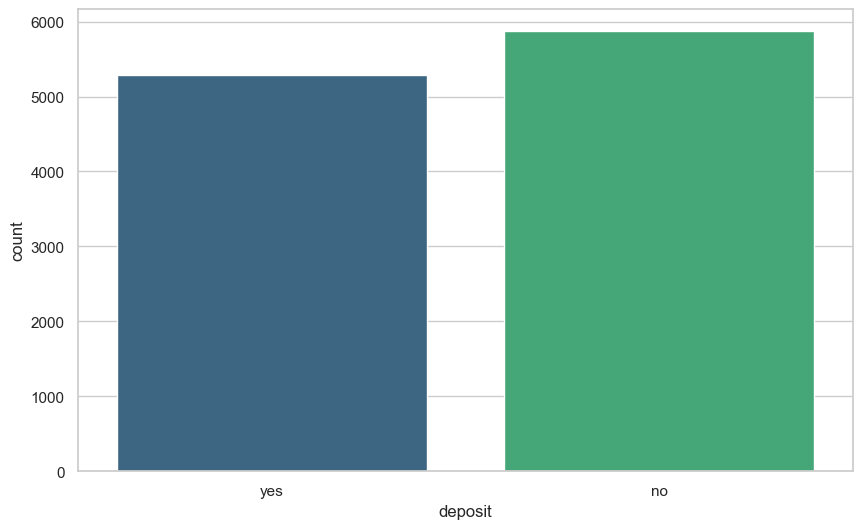

In [596]:
sns.countplot(data=df, x='deposit', palette='viridis')

In [597]:
plt.show()

<Axes: xlabel='age', ylabel='Count'>

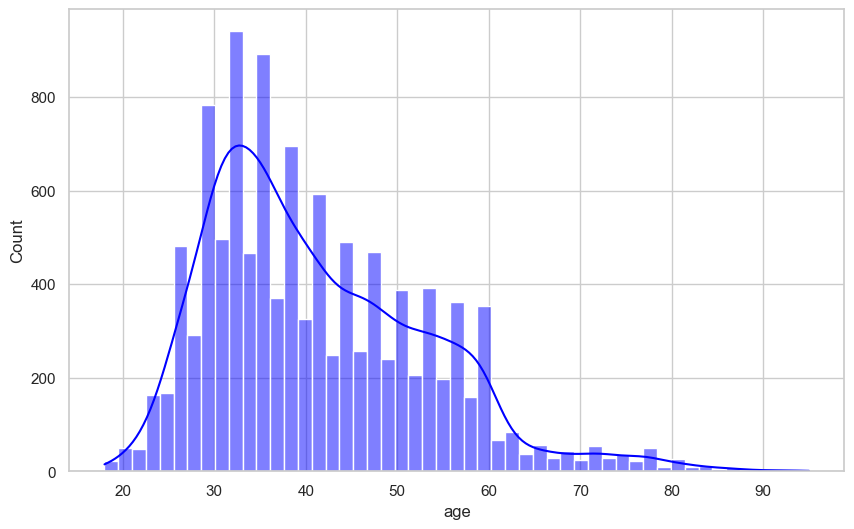

In [598]:
sns.histplot(df['age'], kde=True, color='blue')

In [599]:
plt.show()

<Axes: xlabel='balance', ylabel='Count'>

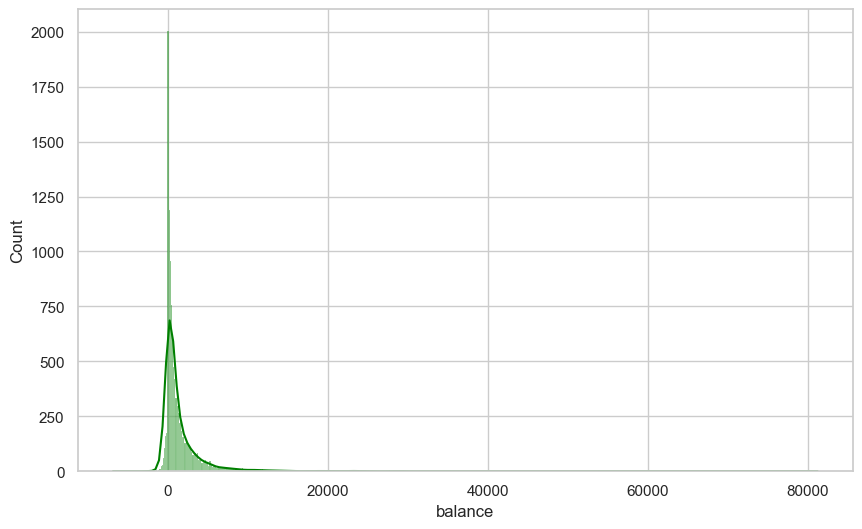

In [600]:
sns.histplot(df['balance'], kde=True, color='green')

In [601]:
plt.show()

In [602]:
binary_cols = ['default', 'housing', 'loan', 'deposit']

In [603]:
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'yes': 1, 'no': 0})

In [604]:
month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

In [605]:
df['month'] = df['month'].map(month_map)

In [606]:
df.drop('day', axis=1, inplace=True)

<Axes: xlabel='month', ylabel='count'>

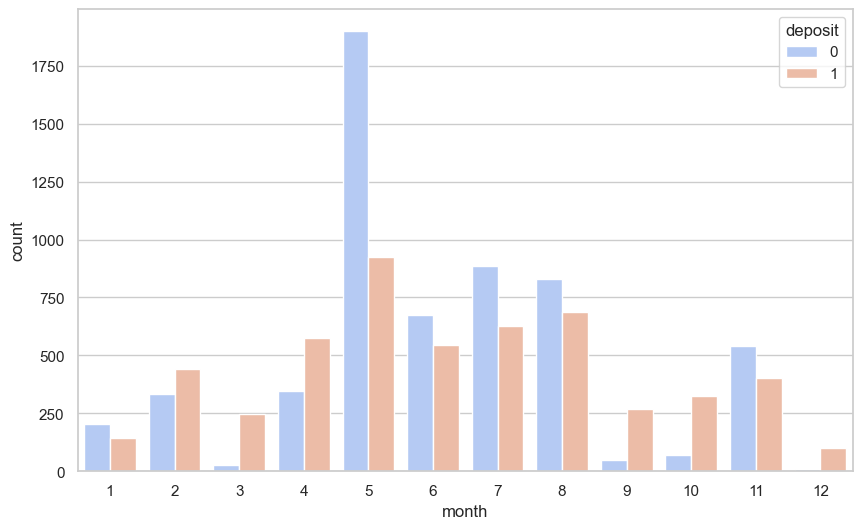

In [607]:
sns.countplot(data=df, x='month', hue='deposit', palette='coolwarm')

In [608]:
plt.show()

In [609]:
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 100], labels=['young', 'middle', 'senior'])

<Axes: xlabel='age_group', ylabel='count'>

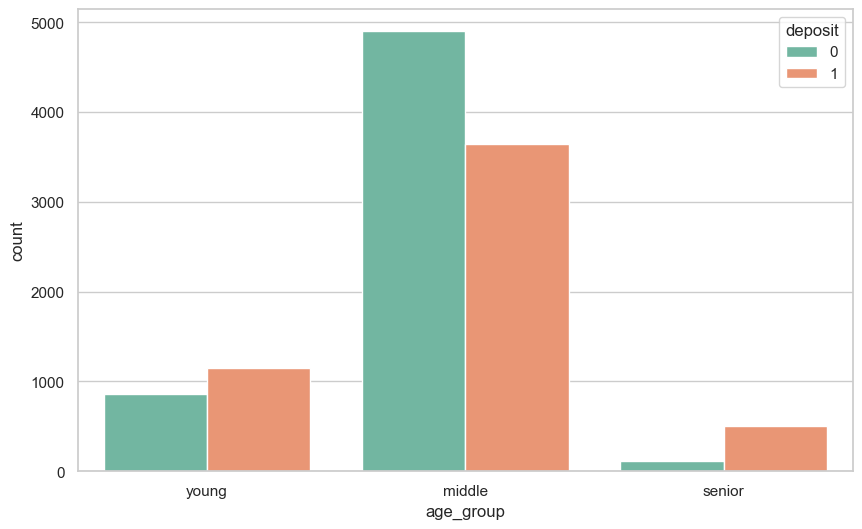

In [610]:
sns.countplot(data=df, x='age_group', hue='deposit', palette='Set2')

In [611]:
plt.show()

In [612]:
age_map = {'young': 0, 'middle': 1, 'senior': 2}

In [613]:
df['age_group'] = df['age_group'].map(age_map)

In [614]:
df.drop('age', axis=1, inplace=True)

In [615]:
te = TargetEncoder()

In [616]:
df['job'] = te.fit_transform(df[['job']], df['deposit'])

<Axes: xlabel='job', ylabel='Count'>

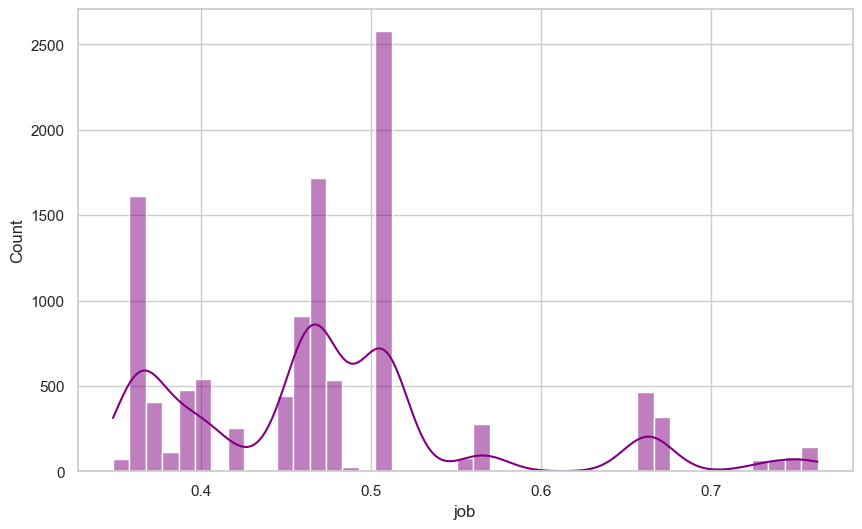

In [617]:
sns.histplot(df['job'], kde=True, color='purple')

In [618]:
plt.show()

In [619]:
marital_map = {'single': 0, 'married': 1, 'divorced': 2}

In [620]:
df['marital'] = df['marital'].map(marital_map)

In [621]:
education_map = {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}

In [622]:
df['education'] = df['education'].map(education_map)

In [623]:
cat_cols = ['contact', 'poutcome']

In [624]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [625]:
numeric_cols = ['balance']

In [626]:
scaler = RobustScaler()

In [627]:
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

<Axes: xlabel='balance', ylabel='Count'>

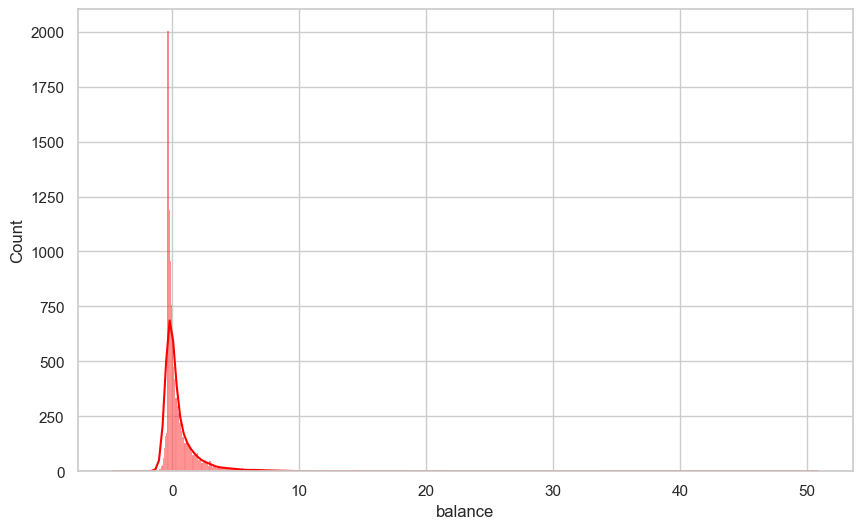

In [628]:
sns.histplot(df['balance'], kde=True, color='red')

In [629]:
plt.show()

In [630]:
X = df.drop('deposit', axis=1)

In [631]:
y = df['deposit']

In [632]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [633]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [634]:
rf_scores = cross_val_score(rf_model, X, y, cv=kf)

In [635]:
print(f'Random Forest CV Mean: {rf_scores.mean():.4f}')

Random Forest CV Mean: 0.8401


In [636]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

In [637]:
gb_scores = cross_val_score(gb_model, X, y, cv=kf)

In [638]:
print(f'Gradient Boosting CV Mean: {gb_scores.mean():.4f}')

Gradient Boosting CV Mean: 0.8407


In [639]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [640]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [641]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [642]:
rf_pred = rf_model.predict(X_test)

In [643]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



In [644]:
gb_pred = gb_model.predict(X_test)

In [645]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1166
           1       0.81      0.83      0.82      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233

